# 02 · Sentiment model evaluation — A vs B vs C (FinBERT-IN)

Headline-level, **target-aware** sentiment for TCS on the 2024 test set (148 headlines, never trained on).

| Model | Encoder | Sentiment head | Input |
|---|---|---|---|
| **A** | ProsusAI FinBERT | ProsusAI (as shipped) | full headline |
| **B** | ProsusAI FinBERT | fine-tuned: PhraseBank AllAgree + our 450 labels | target pair + `<t>/<o>/<c>/<a>/<m>` markers |
| **C** FinBERT-IN | DAPT on 189k Indian business articles | same fine-tuning as B | same as B |

> **Label caveat.** `label_source` below says whether the gold labels are the user's blind labels or Claude's provisional drafts.
> Until `data/labels/test_to_label.csv` is filled in, every number here is *agreement with the drafts*, not ground truth.
> Results are from one fine-tuning seed (`--quick`).

In [1]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RES = ROOT / "results" / "sentiment"
LABELS = ["positive", "neutral", "negative"]
MODELS = {"A": "preds_A_full_s0.csv", "B": "preds_B_s0.csv", "C": "preds_C_s0.csv"}
test = pd.read_csv(ROOT / "data/labels/test_final.csv")
P = {m: pd.read_csv(RES / f).merge(test[["id", "title", "article_type", "label_source"]], on="id") for m, f in MODELS.items()}
y = P["A"]["y"].values
assert all((P[m]["y"].values == y).all() for m in P), "row order differs"
summ = json.loads((RES / "summary.json").read_text())
print("test rows:", len(y), "| gold label source:", test.label_source.value_counts().to_dict())
print("gold distribution:", pd.Series(y).value_counts().to_dict())

test rows: 148 | gold label source: {'claude_provisional': 148}
gold distribution: {'neutral': 63, 'positive': 55, 'negative': 30}


## 1 · Overall metrics with bootstrap 95% CIs

In [2]:
def prf(y, p):
    out = {}
    for c in LABELS:
        tp = np.sum((y == c) & (p == c)); fp = np.sum((y != c) & (p == c)); fn = np.sum((y == c) & (p != c))
        pr = tp / (tp + fp) if tp + fp else 0.0; rc = tp / (tp + fn) if tp + fn else 0.0
        out[c] = (pr, rc, 2 * pr * rc / (pr + rc) if pr + rc else 0.0)
    return out
def macro_f1(y, p): return float(np.mean([v[2] for v in prf(y, p).values()]))
def flips(y, p): return int(np.sum(((y == "positive") & (p == "negative")) | ((y == "negative") & (p == "positive"))))
rng = np.random.default_rng(0); B = 2000; idx = [rng.integers(0, len(y), len(y)) for _ in range(B)]
rows = []
for m, df in P.items():
    p = df["pred"].values; bs = [macro_f1(y[i], p[i]) for i in idx]; ba = [(y[i] == p[i]).mean() for i in idx]
    r = prf(y, p)
    rows.append({"model": m, "accuracy": (y == p).mean(), "acc 95% CI": f"[{np.percentile(ba, 2.5):.3f}, {np.percentile(ba, 97.5):.3f}]",
                 "macro-F1": macro_f1(y, p), "F1 95% CI": f"[{np.percentile(bs, 2.5):.3f}, {np.percentile(bs, 97.5):.3f}]",
                 **{f"F1 {c}": r[c][2] for c in LABELS}, "sign flips": flips(y, p)})
overall = pd.DataFrame(rows).set_index("model").round(3); overall

,accuracy,acc 95% CI,macro-F1,F1 95% CI,F1 positive,F1 neutral,F1 negative,sign flips
model,,,,,,,,
A,0.757,"[0.682, 0.824]",0.757,"[0.680, 0.826]",0.727,0.780,0.762,9
B,0.811,"[0.750, 0.872]",0.809,"[0.741, 0.870]",0.814,0.817,0.794,7
C,0.838,"[0.777, 0.892]",0.839,"[0.776, 0.897]",0.817,0.852,0.847,6


In [3]:
rows = []
for m, df in P.items():
    r = prf(y, df["pred"].values)
    for c in LABELS: rows.append({"model": m, "class": c, "precision": r[c][0], "recall": r[c][1], "F1": r[c][2], "support": int((y == c).sum())})
pd.DataFrame(rows).pivot(index="class", columns="model", values=["precision", "recall", "F1"]).round(3)

precision               recall                   F1              
model            A      B      C      A      B      C      A      B      C
class                                                                     
negative     0.727  0.711  0.862  0.800  0.900  0.833  0.762  0.794  0.847
neutral      0.800  0.904  0.881  0.762  0.746  0.825  0.780  0.817  0.852
positive     0.727  0.793  0.783  0.727  0.836  0.855  0.727  0.814  0.817

## 2 · Confusion matrices (rows = gold, columns = predicted)

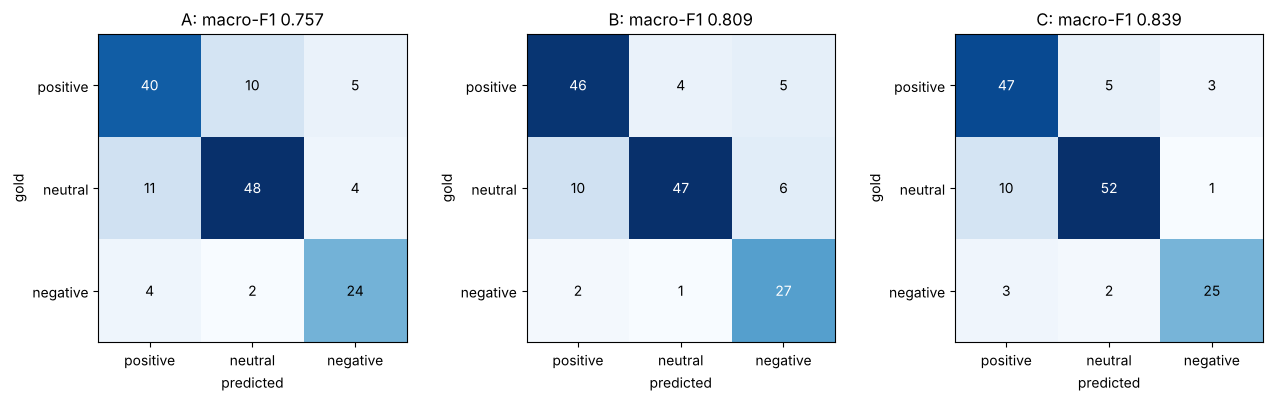

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (m, df) in zip(axes, P.items()):
    cm = pd.crosstab(pd.Categorical(y, LABELS), pd.Categorical(df["pred"], LABELS), dropna=False).values
    ax.imshow(cm, cmap="Blues")
    for i in range(3):
        for j in range(3): ax.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks(range(3), LABELS); ax.set_yticks(range(3), LABELS); ax.set_title(f"{m}: macro-F1 {macro_f1(y, df['pred'].values):.3f}")
    ax.set_xlabel("predicted"); ax.set_ylabel("gold")
plt.tight_layout(); plt.show()

## 3 · Paired significance

* **McNemar (exact)** on per-headline correctness: does one model fix more headlines than it breaks?
* **Paired bootstrap** of the macro-F1 difference (same resamples for both models).

In [5]:
def mcnemar(a, b):
    ca, cb = (P[a]["pred"].values == y), (P[b]["pred"].values == y)
    fixes, breaks = int(np.sum(~cb & ca)), int(np.sum(cb & ~ca))      # a right & b wrong / b right & a wrong
    p = stats.binomtest(fixes, fixes + breaks, 0.5).pvalue if fixes + breaks else 1.0
    return fixes, breaks, p
rows = []
for a, b in [("B", "A"), ("C", "B"), ("C", "A")]:
    fx, br, p = mcnemar(a, b)
    d = [macro_f1(y[i], P[a]["pred"].values[i]) - macro_f1(y[i], P[b]["pred"].values[i]) for i in idx]
    rows.append({"comparison": f"{a} vs {b}", "first right, second wrong": fx, "first wrong, second right": br, "McNemar p": round(p, 4),
                 "ΔF1": round(macro_f1(y, P[a]['pred'].values) - macro_f1(y, P[b]['pred'].values), 3),
                 "ΔF1 95% CI": f"[{np.percentile(d, 2.5):+.3f}, {np.percentile(d, 97.5):+.3f}]", "P(Δ≤0)": round(float(np.mean(np.array(d) <= 0)), 3)})
pd.DataFrame(rows).set_index("comparison")

,"first right, second wrong","first wrong, second right",McNemar p,ΔF1,ΔF1 95% CI,P(Δ≤0)
comparison,,,,,,
B vs A,12,4,0.0768,0.052,"[-0.001, +0.107]",0.029
C vs B,10,6,0.4545,0.031,"[-0.022, +0.088]",0.134
C vs A,14,2,0.0042,0.083,"[+0.032, +0.139]",0.001


## 4 · Where the gains come from: by headline role and article type

In [6]:
def by(col, min_n=5):
    rows = []
    for g, ix in P["A"].groupby(col).groups.items():
        ix = np.array(list(ix))
        if len(ix) < min_n: continue
        rows.append({col: g, "n": len(ix), **{f"{m} acc": (P[m]["pred"].values[ix] == y[ix]).mean() for m in P},
                     **{f"{m} F1": macro_f1(y[ix], P[m]["pred"].values[ix]) for m in P}})
    return pd.DataFrame(rows).set_index(col).sort_values("n", ascending=False).round(3)
by_role = by("role"); by_role

,n,A acc,B acc,C acc,A F1,B F1,C F1
role,,,,,,,
primary,65,0.646,0.692,0.769,0.622,0.661,0.753
list_member,51,0.902,0.941,0.941,0.857,0.902,0.929
co_mention,32,0.750,0.844,0.812,0.721,0.754,0.781


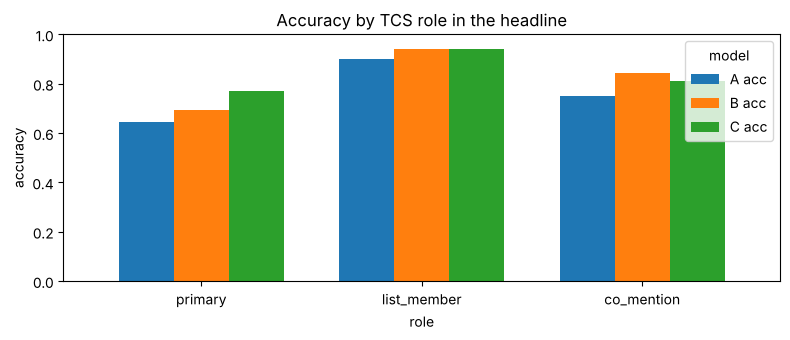

,n,A acc,B acc,C acc,A F1,B F1,C F1
article_type,,,,,,,
other,77,0.753,0.818,0.857,0.759,0.814,0.857
stocks_to_watch,23,0.957,1.000,0.957,0.326,0.667,0.326
market_wrap,9,0.556,0.556,0.667,0.556,0.556,0.746
results,8,0.875,0.875,1.000,0.822,0.822,1.000
buy_sell_reco,7,0.429,0.714,0.571,0.250,0.463,0.296
deal_win,6,0.500,0.500,0.667,0.524,0.524,0.583
results_preview,6,0.500,0.667,0.500,0.522,0.667,0.522


In [7]:
ax = by_role[[f"{m} acc" for m in P]].plot.bar(figsize=(8, 3.5), rot=0, width=0.75)
ax.set_ylabel("accuracy"); ax.set_ylim(0, 1); ax.set_title("Accuracy by TCS role in the headline"); ax.legend(title="model"); plt.tight_layout(); plt.show()
by("article_type")

## 5 · Calibration — are the probabilities trustworthy?

The volatility features use **probabilities** (`P(pos) − P(neg)`, magnitude), not just labels, so calibration matters.
ECE = expected calibration error over 5 confidence bins; Brier = mean squared error of the probability vector.

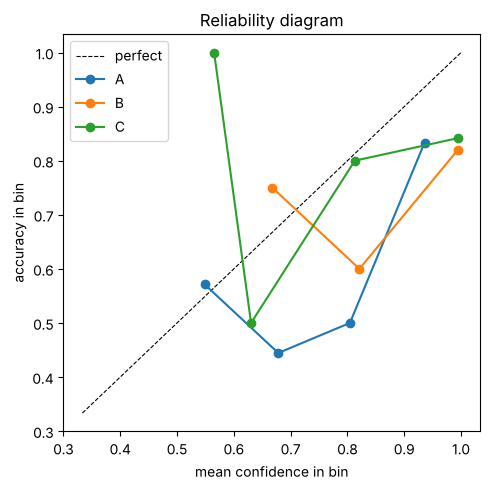

,ECE,Brier,mean confidence,accuracy
model,,,,
A,0.131,0.386,0.886,0.757
B,0.173,0.367,0.980,0.811
C,0.152,0.313,0.978,0.838


In [8]:
def calib(df, bins=5):
    pr = df[[f"p_{c}" for c in ["positive", "negative", "neutral"]]].values
    names = np.array(["positive", "negative", "neutral"]); conf = pr.max(1); pred = names[pr.argmax(1)]
    correct = (pred == y).astype(float)
    onehot = np.stack([(y == c).astype(float) for c in names], 1)
    edges = np.linspace(1/3, 1, bins + 1); ece, pts = 0.0, []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf >= lo) & (conf <= hi if hi == 1 else conf < hi)
        if m.sum(): ece += m.mean() * abs(correct[m].mean() - conf[m].mean()); pts.append((conf[m].mean(), correct[m].mean(), m.sum()))
    return ece, float(np.mean(np.sum((pr - onehot) ** 2, 1))), float(conf.mean()), pts
fig, ax = plt.subplots(figsize=(5, 5)); ax.plot([1/3, 1], [1/3, 1], "k--", lw=0.8, label="perfect")
rows = []
for m, df in P.items():
    ece, brier, mc, pts = calib(df); rows.append({"model": m, "ECE": ece, "Brier": brier, "mean confidence": mc, "accuracy": (df.pred.values == y).mean()})
    ax.plot([p[0] for p in pts], [p[1] for p in pts], "o-", label=m)
ax.set_xlabel("mean confidence in bin"); ax.set_ylabel("accuracy in bin"); ax.set_title("Reliability diagram"); ax.legend(); plt.tight_layout(); plt.show()
pd.DataFrame(rows).set_index("model").round(3)

### 5b · After temperature scaling (`bert/calibrate.py`)

`p = softmax(z / T)`, with one temperature per model fitted on the 68 dev headlines (never on this test set).
Dividing every logit by the same T > 0 cannot change the arg-max, so the **labels — and every accuracy/F1 number above — are identical**; only the probabilities move.
Bin counts are printed on each point: bins with 2–5 headlines are noise.

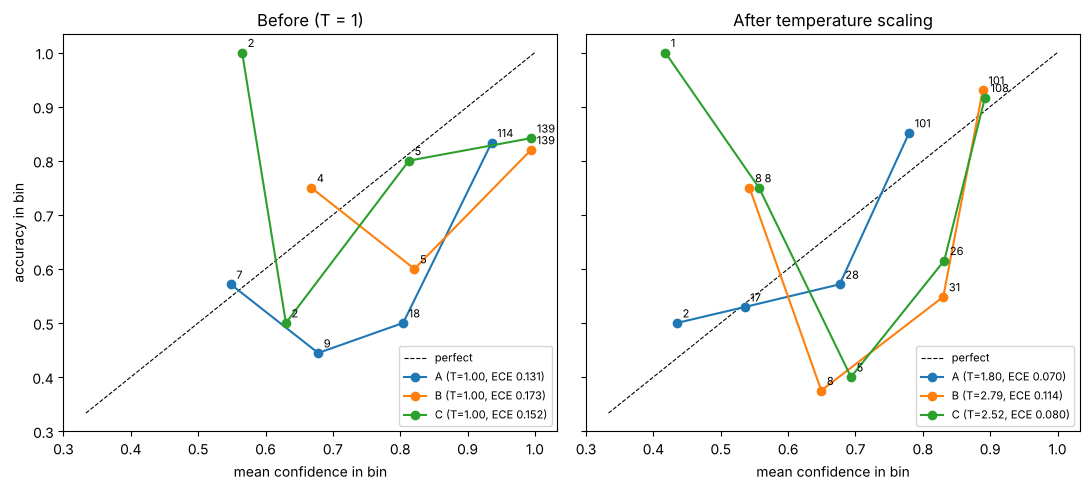

,T,labels identical to T=1,ECE before,ECE after,mean conf before,mean conf after,accuracy
model,,,,,,,
A,1.802,True,0.131,0.070,0.886,0.727,0.757
B,2.787,True,0.173,0.114,0.980,0.845,0.811
C,2.524,True,0.152,0.080,0.978,0.854,0.838


In [9]:
cal = json.loads((RES / "calibration.json").read_text())
def probs(m, T):
    z = pd.read_csv(RES / f"preds_logits_{m}_test.csv").set_index("id").loc[P[m]["id"]]
    zz = z[[f"z_{c}" for c in ["positive", "negative", "neutral"]]].to_numpy() / T
    e = np.exp(zz - zz.max(1, keepdims=True)); return e / e.sum(1, keepdims=True)
def bins(pr, nb=5):
    names = np.array(["positive", "negative", "neutral"]); conf = pr.max(1); ok = names[pr.argmax(1)] == y
    edges = np.linspace(1/3, 1, nb + 1); pts = []; ece = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf >= lo) & ((conf <= hi) if hi == 1 else (conf < hi))
        if m.any(): pts.append((conf[m].mean(), ok[m].mean(), int(m.sum()))); ece += m.mean() * abs(ok[m].mean() - conf[m].mean())
    return pts, ece, names[pr.argmax(1)]
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True); rows = []
for ax, title, use_T in [(axes[0], "Before (T = 1)", False), (axes[1], "After temperature scaling", True)]:
    ax.plot([1/3, 1], [1/3, 1], "k--", lw=0.8, label="perfect")
    for m in "ABC":
        T = cal[m]["T"] if use_T else 1.0; pr = probs(m, T); pts, e, pred = bins(pr)
        ax.plot([p[0] for p in pts], [p[1] for p in pts], "o-", label=f"{m} (T={T:.2f}, ECE {e:.3f})")
        for cx, ac, n in pts: ax.annotate(str(n), (cx, ac), textcoords="offset points", xytext=(4, 4), fontsize=8)
        if use_T: rows.append({"model": m, "T": T, "labels identical to T=1": bool((pred == bins(probs(m, 1.0))[2]).all()),
                               "ECE before": bins(probs(m, 1.0))[1], "ECE after": e,
                               "mean conf before": probs(m, 1.0).max(1).mean(), "mean conf after": pr.max(1).mean(), "accuracy": (pred == y).mean()})
    ax.set_title(title); ax.set_xlabel("mean confidence in bin"); ax.legend(fontsize=8, loc="lower right")
axes[0].set_ylabel("accuracy in bin"); plt.tight_layout(); plt.show()
pd.DataFrame(rows).set_index("model").round(3)

## 6 · Contrast and target handling — minimal pairs (40 templated sentences, 20 pairs)

In [10]:
mp = {r["run"]: r["pairs"] for r in summ["runs"]}
t = pd.DataFrame({k.split("_")[0] if k != "A_full" else "A": {**v["by_test"], "ALL rows": v["acc"], "ALL pairs (both right)": v["pair_acc"]} for k, v in mp.items()})
t.round(2)

,A,B,C
concessive_main_first,0.88,1.00,1.00
concessive_concession_first,0.88,1.00,1.00
even_as,0.75,1.00,1.00
adversative_after_but,0.38,0.88,1.00
entity_switch,0.50,0.38,0.38
ALL rows,0.68,0.85,0.88
ALL pairs (both right),0.40,0.75,0.80


## 7 · Agreement between models and the effect of each step

In [11]:
def kappa(a, b):
    po = (a == b).mean(); pe = sum((a == c).mean() * (b == c).mean() for c in LABELS); return (po - pe) / (1 - pe)
pd.DataFrame({m1: {m2: kappa(P[m1].pred.values, P[m2].pred.values) for m2 in P} for m1 in P}).round(3).rename_axis("Cohen's κ")

,A,B,C
Cohen's κ,,,
A,1.000,0.835,0.832
B,0.835,1.000,0.834
C,0.832,0.834,1.000


In [12]:
ca, cc = P["A"].pred.values == y, P["C"].pred.values == y
print(f"C fixes {np.sum(cc & ~ca)} headlines A got wrong; breaks {np.sum(ca & ~cc)} that A got right; both wrong on {np.sum(~ca & ~cc)}")
print("\nfixed by C, by role:", P['C'][cc & ~ca].role.value_counts().to_dict())
print("broken by C, by role:", P['C'][ca & ~cc].role.value_counts().to_dict())
print("\nC error types (gold → predicted):")
print(pd.crosstab(P["C"].y[~cc], P["C"].pred[~cc]))

C fixes 14 headlines A got wrong; breaks 2 that A got right; both wrong on 22

fixed by C, by role: {'primary': 9, 'list_member': 3, 'co_mention': 2}
broken by C, by role: {'list_member': 1, 'primary': 1}

C error types (gold → predicted):
pred      negative  neutral  positive
y                                    
negative         0        2         3
neutral          1        0        10
positive         3        5         0


### Example headlines (truncated) — where C fixes A, and where both still fail

In [13]:
show = lambda m: pd.DataFrame({"headline": P["C"].title[m].str[:95], "gold": y[m], "A": P["A"].pred[m], "C": P["C"].pred[m],
                                  "C P(pos)−P(neg)": (P["C"].p_positive - P["C"].p_negative)[m].round(2)}).head(8)
display(show(cc & ~ca)); display(show(~ca & ~cc))

,headline,gold,A,C,C P(pos)−P(neg)
1,Markets to take cues from quarterly earnings o...,neutral,positive,neutral,0.00
30,TCS bags Nordic deal; Wipro in Canada,positive,neutral,positive,1.00
49,TCS trades flat ahead of March 2024 quarter re...,neutral,negative,neutral,-0.07
54,TCS trades firm in weak market on strong Q4 sh...,positive,negative,positive,1.00
56,TCS shares defy market sell-off as target pric...,positive,neutral,positive,1.00
60,TCS reports all-time high order book; Would In...,positive,neutral,positive,0.78
63,"FIIs raise bet on TCS, Infosys, 4 other IT sto...",positive,neutral,positive,0.58
73,Stock Radar: TCS showing signs of bottoming ou...,positive,negative,positive,0.95


,headline,gold,A,C,C P(pos)−P(neg)
4,Q3 preview: TCS likely to report single-digit ...,negative,positive,positive,1.00
23,Xerox turns into a leaky account for HCLTech a...,neutral,negative,negative,-0.98
27,"Technical Breakout Stocks: How to trade TCS, I...",positive,neutral,neutral,-0.00
28,HEG and TCS remain Mehta Equities’ top stock r...,positive,neutral,neutral,0.00
31,"Tata Sons to sell TCS shares worth Rs 9,000 cr...",negative,neutral,neutral,-0.01
33,"Tata Sons plans to sell Rs 9,300 crore slice o...",negative,neutral,neutral,0.00
43,Mcap of 5 of top-10 firms hit Rs 1.97 trn; TCS...,negative,positive,positive,0.83
59,Hot Stocks: Brokerage view on Zomato & TCS; Ex...,neutral,positive,positive,0.99


## 8 · Conclusions

**Caveat first:** gold labels are Claude's provisional drafts and this is one fine-tuning seed, so read the numbers as *agreement with a careful annotator*, not final accuracy.

| Finding | Evidence |
|---|---|
| **C (FinBERT-IN) is the best headline reader** | macro-F1 A 0.757 → B 0.809 → **C 0.839**; sign flips 9 → 7 → 6 |
| C vs off-the-shelf is significant | McNemar: C fixes 14 headlines A got wrong, breaks 2 (p = 0.004); ΔF1 +0.083, 95% CI [+0.032, +0.139] |
| Domain pretraining on top of the same fine-tuning (C − B) is **not yet significant** | ΔF1 +0.031, CI [−0.022, +0.088]; 10 fixes vs 6 breaks (p = 0.45) |
| The gain is on **TCS-primary headlines** | accuracy A 0.646 → B 0.692 → C 0.769; list headlines were already easy (≈0.9–0.94) |
| Contrast handling is solved by fine-tuning | "X, but Y": A 0.38 → B 0.88 → C 1.00; concessives 0.88 → 1.00 |
| **Company switch is not solved** | "Infosys falls, TCS gains": A 0.50, B 0.38, C 0.38 — the `<t>/<o>` markers are not being used yet (too few such training examples) |
| Main error: **over-optimism** | 10 of C's 24 errors are neutral → positive |
| **Fine-tuned models were over-confident; temperature scaling fixes it** | before: mean confidence 0.98 vs accuracy 0.81–0.84 (ECE 0.15–0.17). After T = 2.5–2.8 (fitted on dev): ECE C 0.152 → 0.080, B 0.173 → 0.114, A 0.131 → 0.070; labels and F1 unchanged (§5b) |

**Implications for the volatility study.** Over-confidence pushes `P(pos) − P(neg)` towards ±1, so the *magnitude* feature becomes nearly binary (see notebook 03, §1). Temperature scaling (§5b) removed the saturation, but the calibrated magnitude still adds nothing in the volatility ladder (see `results/ladder/summary.md`). Remaining steps: (1) done — calibration, (2) add **company-switch training examples** (synthetic pairs are fine for training here, kept separate from the minimal-pair test), (3) label the blind test set and run 3 seeds.

In [14]:
best = overall["macro-F1"].idxmax()
print(f"best model on this test set: {best} (macro-F1 {overall.loc[best, 'macro-F1']:.3f})")

best model on this test set: C (macro-F1 0.839)
